# Stock Return Prediction — Algorithm Comparison
## ARIMA · Multiple Linear Regression · CNN · LSTM · GRU · Feedforward NN · DeepGraphCNN

This notebook trains **7 different models** on the same dataset and compares them using R², RMSE, MAE and Directional Accuracy.

**Target:** Predict next-day return of AAPL  
**Features:** 20-day sliding window of standardised returns for 20 Fortune 500 stocks  
**Graph models:** Stocks connected by Pearson correlation ≥ 0.3


## 1. Install & Imports

In [1]:
 !pip install torch torch-geometric statsmodels scikit-learn networkx matplotlib pandas numpy

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('inline')   # use 'Agg' when running as script
import matplotlib.pyplot as plt
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch_geometric.data import Data
from torch_geometric.data import DataLoader as GeoDataLoader
from torch_geometric.nn import GCNConv, global_sort_pool
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from matplotlib.patches import Patch

np.random.seed(42); torch.manual_seed(42)
DEVICE = torch.device("cpu")
print("Imports OK ✓")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 10.7 MB/s eta 0:00:00
Imports OK ✓



A factor model (market + sector + idiosyncratic) produces correlated price series for 20 Fortune 500 stocks over 2018–2024.

In [2]:
!pip install yfinance
import yfinance as yf

tickers = ["AAPL","MSFT","AMZN","GOOGL","JPM","BAC","WMT","PG",
           "XOM","CVX","KO","PEP","TSLA","NVDA","V","MA","HD","UNH","NFLX","IBM"]

START_DATE = "2018-01-01"
END_DATE   = "2024-12-31"
TARGET     = "AAPL"

# ── Download adjusted close prices ──────────────────────────────────────────
raw = yf.download(
    tickers,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,   # already split/dividend-adjusted
    progress=False
)["Close"]

# Keep only the 20 tickers we need (yfinance preserves column order)
df = raw[tickers].copy()

# ── Handle missing data ─────────────────────────────────────────────────────
# Forward-fill short gaps (holidays, halts), then drop any remaining NaNs
df = df.ffill().dropna()

# ── Returns ─────────────────────────────────────────────────────────────────
returns_df = df.pct_change().dropna()

# ── ticker_meta kept for graph colour coding ─────────────────────────────────
ticker_meta = {
    "AAPL":("tech",None),  "MSFT":("tech",None),  "AMZN":("tech",None),
    "GOOGL":("tech",None), "NVDA":("tech",None),  "NFLX":("tech",None),
    "JPM":("fin",None),   "BAC":("fin",None),   "V":("fin",None),
    "MA":("fin",None),    "WMT":("cons",None),  "PG":("cons",None),
    "KO":("cons",None),  "PEP":("cons",None),  "HD":("cons",None),
    "UNH":("cons",None), "IBM":("cons",None),
    "XOM":("energy",None),"CVX":("energy",None),"TSLA":("tech",None),
}

print(f"Price shape  : {df.shape}")
print(f"Returns shape: {returns_df.shape}")
print(f"Date range   : {df.index[0].date()} → {df.index[-1].date()}")
print(f"Target stock : {TARGET}")
print(f"Missing cols : {df.columns[df.isnull().any()].tolist()}")
df.tail(3)

Price shape  : (1760, 20)
Returns shape: (1759, 20)
Date range   : 2018-01-02 → 2024-12-30
Target stock : AAPL
Missing cols : []


Ticker,AAPL,MSFT,AMZN,GOOGL,JPM,BAC,WMT,PG,XOM,CVX,KO,PEP,TSLA,NVDA,V,MA,HD,UNH,NFLX,IBM
Date,,,,,,,,,,,,,,,,,,,,
2024-12-26,257.612701,433.911407,227.050003,194.69989,235.823608,43.296780,91.721992,163.381058,102.039894,136.268204,60.361832,145.284378,454.130005,139.884171,317.991058,531.374390,382.967926,495.016174,92.414001,217.982895
2024-12-27,254.201355,426.404053,223.750000,191.87294,233.912888,43.092686,90.605011,162.776154,102.030319,136.287140,60.246071,145.713257,431.660004,136.965103,315.761505,527.459656,380.758148,493.892822,90.754997,215.937714
2024-12-30,250.829773,420.758728,221.300003,190.35994,232.118576,42.674789,89.527534,160.433350,101.340408,135.406967,59.840897,144.598175,417.410004,137.444962,312.441986,520.868835,377.433807,491.771942,90.042999,213.485428


## 3. Exploratory Plots
### 3A. Normalised Stock Prices & Correlation Heatmap

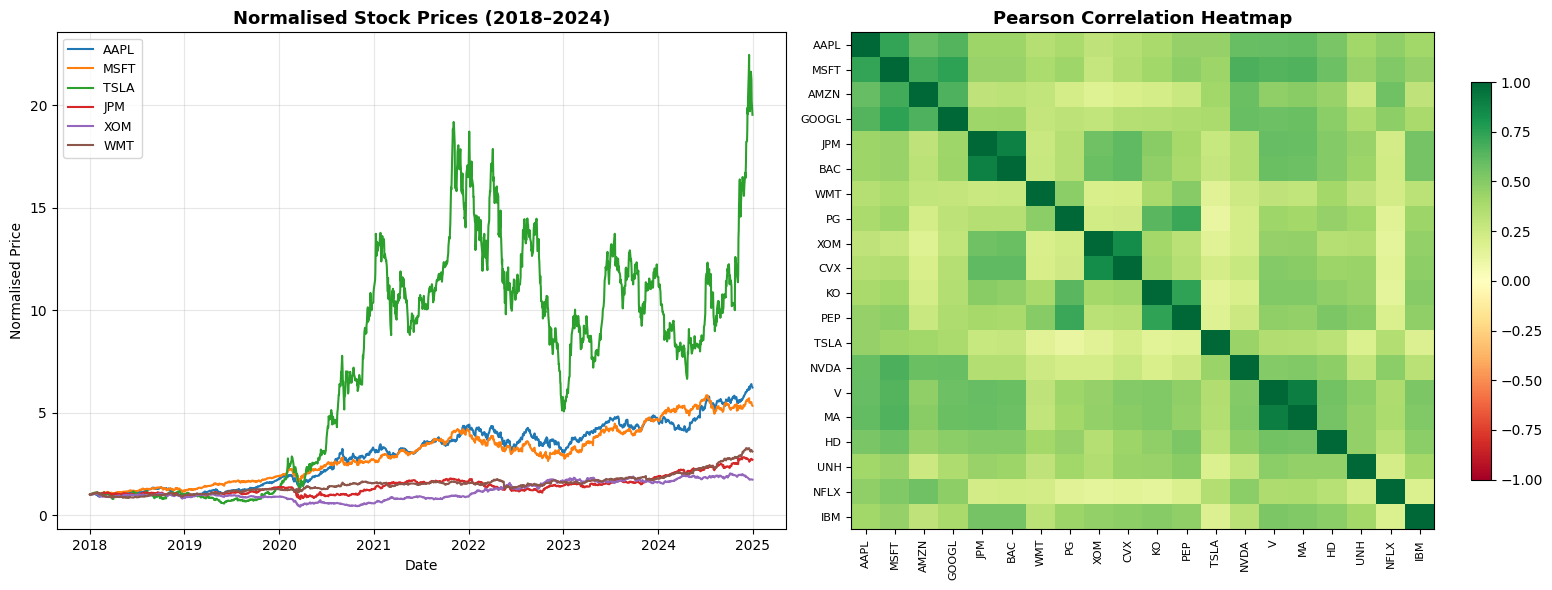

In [3]:
corr = returns_df.corr(method="pearson")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for t in ["AAPL","MSFT","TSLA","JPM","XOM","WMT"]:
    axes[0].plot(df.index, df[t]/df[t].iloc[0], label=t, linewidth=1.5)
axes[0].set_title("Normalised Stock Prices (2018–2024)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Date"); axes[0].set_ylabel("Normalised Price")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

im = axes[1].imshow(corr.values, cmap=plt.cm.RdYlGn, vmin=-1, vmax=1, aspect='auto')
axes[1].set_xticks(range(len(tickers))); axes[1].set_xticklabels(tickers, rotation=90, fontsize=8)
axes[1].set_yticks(range(len(tickers))); axes[1].set_yticklabels(tickers, fontsize=8)
plt.colorbar(im, ax=axes[1], shrink=0.8)
axes[1].set_title("Pearson Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig("B_stock_prices_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()


### 3B. Pearson Correlation Graph

Graph: 20 nodes, 145 edges


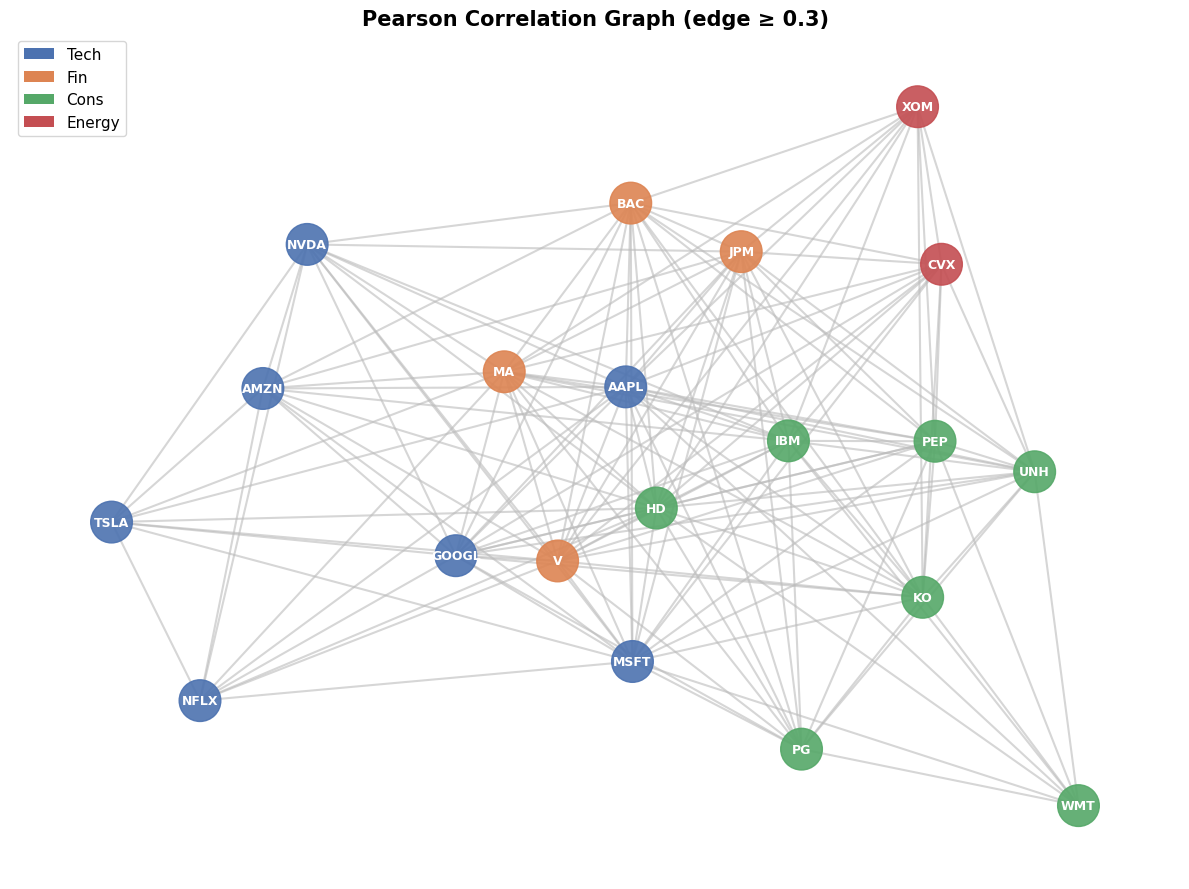

In [4]:
adj_vals = corr.values.copy()
adj_vals[adj_vals >= 0.3] = 1
adj_vals[adj_vals <  0.3] = 0
np.fill_diagonal(adj_vals, 0)
adj = pd.DataFrame(adj_vals, index=corr.index, columns=corr.columns)
G   = nx.Graph(adj)
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

sector_colors = {"tech":"#4C72B0","fin":"#DD8452","cons":"#55A868","energy":"#C44E52"}
fig, ax = plt.subplots(figsize=(12, 9))
pos = nx.spring_layout(G, k=0.7, seed=42)
nc  = [sector_colors[ticker_meta[t][0]] for t in tickers]
nx.draw_networkx_nodes(G, pos, node_size=900, node_color=nc, alpha=0.9, ax=ax)
nx.draw_networkx_edges(G, pos, edge_color="#bbbbbb", width=1.5, alpha=0.6, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, font_color="white", font_weight="bold", ax=ax)
leg = [Patch(facecolor=c, label=s.capitalize()) for s, c in sector_colors.items()]
ax.legend(handles=leg, loc="upper left", fontsize=11)
ax.set_title("Pearson Correlation Graph (edge ≥ 0.3)", fontsize=15, fontweight="bold")
ax.axis("off"); plt.tight_layout()
plt.savefig("A_correlation_graph.png", dpi=150, bbox_inches="tight"); plt.show()


## 4. Dataset Preparation

In [5]:
WINDOW  = 20   # look-back days
HORIZON = 1    # predict 1-day-ahead

scaler    = StandardScaler()
scaled    = scaler.fit_transform(returns_df.values)
scaled_df = pd.DataFrame(scaled, index=returns_df.index, columns=returns_df.columns)
target_series = returns_df[TARGET].values

def make_sequences(data_2d, target_1d, window=WINDOW, horizon=HORIZON):
    X, y = [], []
    for i in range(window, len(target_1d) - horizon):
        X.append(data_2d[i-window:i])
        y.append(target_1d[i+horizon-1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_all, y_all = make_sequences(scaled, target_series)
n       = len(X_all)
n_train = int(0.70 * n); n_val = int(0.15 * n)

X_train, y_train = X_all[:n_train], y_all[:n_train]
X_val,   y_val   = X_all[n_train:n_train+n_val], y_all[n_train:n_train+n_val]
X_test,  y_test  = X_all[n_train+n_val:], y_all[n_train+n_val:]

print(f"Train: {len(y_train)}  Val: {len(y_val)}  Test: {len(y_test)}")

PALETTE = {
    "ARIMA":"#E45756","MLR":"#F28E2B","CNN":"#59A14F",
    "LSTM":"#4E79A7","GRU":"#B07AA1","NN":"#FF9DA7","DeepGraphCNN":"#76B7B2"
}
results = {}; train_curves = {}

def eval_metrics(y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return r2, rmse, mae


Train: 1216  Val: 260  Test: 262


## 5. Model 1 — ARIMA
Walk-forward ARIMA(2,0,2) on the target ticker returns. Classical time-series baseline.

In [6]:
aapl_ret = returns_df[TARGET].values
arima_test_len = min(200, len(y_test))
arima_start    = len(aapl_ret) - arima_test_len - 1
arima_preds = []

for i in range(arima_test_len):
    train_slice = aapl_ret[arima_start+i-150 : arima_start+i]
    try:
        m  = ARIMA(train_slice, order=(2,0,2)).fit()
        fc = m.forecast(steps=1)[0]
    except:
        fc = train_slice[-1]
    arima_preds.append(fc)

arima_preds  = np.array(arima_preds, dtype=np.float32)
arima_actual = y_test[-arima_test_len:]
r2, rmse, mae = eval_metrics(arima_actual, arima_preds)
results["ARIMA"] = {"r2":r2,"rmse":rmse,"mae":mae,"y_pred":arima_preds,"y_true":arima_actual}
print(f"ARIMA  R²={r2:+.4f}  RMSE={rmse:.6f}  MAE={mae:.6f}")


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

ARIMA  R²=-0.0670  RMSE=0.015088  MAE=0.010755


## 6. Model 2 — Multiple Linear Regression
Flattened window fed into sklearn LinearRegression. Simple multivariate baseline.

In [7]:
X_tr_flat = X_train.reshape(len(X_train), -1)
X_te_flat = X_test.reshape(len(X_test), -1)

lr_model = LinearRegression()
lr_model.fit(X_tr_flat, y_train)
lr_pred  = lr_model.predict(X_te_flat).astype(np.float32)

r2, rmse, mae = eval_metrics(y_test, lr_pred)
results["MLR"] = {"r2":r2,"rmse":rmse,"mae":mae,"y_pred":lr_pred,"y_true":y_test}
print(f"MLR    R²={r2:+.4f}  RMSE={rmse:.6f}  MAE={mae:.6f}")


MLR    R²=-0.9465  RMSE=0.019575  MAE=0.015300


## 7. Shared PyTorch Training Loop

In [8]:
def pt_tensors(X, y):
    return torch.tensor(X).to(DEVICE), torch.tensor(y).to(DEVICE)

def train_pt_model(model, X_tr, y_tr, X_vl, y_vl,
                   epochs=80, lr=0.001, patience=12, batch=64):
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    crit  = nn.MSELoss()
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=4, factor=0.5)
    Xt, yt = pt_tensors(X_tr, y_tr)
    Xv, yv = pt_tensors(X_vl, y_vl)
    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch, shuffle=True)
    best_val, pat, best_state = 1e9, 0, None
    tl_hist, vl_hist = [], []
    for ep in range(epochs):
        model.train(); ep_loss = 0
        for xb, yb in loader:
            opt.zero_grad(); loss = crit(model(xb), yb)
            loss.backward(); opt.step(); ep_loss += loss.item()
        model.eval()
        with torch.no_grad(): vl = crit(model(Xv), yv).item()
        sched.step(vl)
        tl_hist.append(ep_loss/len(loader)); vl_hist.append(vl)
        if vl < best_val:
            best_val = vl; best_state = {k:v.clone() for k,v in model.state_dict().items()}; pat = 0
        else:
            pat += 1
        if pat >= patience: break
    model.load_state_dict(best_state)
    return tl_hist, vl_hist

def predict_pt(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X).to(DEVICE)).cpu().numpy()


## 8. Model 3 — 1-D Convolutional Neural Network (CNN)

In [9]:
class CNNModel(nn.Module):
    def __init__(self, n_features, window):
        super().__init__()
        self.conv1 = nn.Conv1d(n_features, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.pool  = nn.AdaptiveAvgPool1d(4)
        self.fc1   = nn.Linear(128*4, 64)
        self.drop  = nn.Dropout(0.3)
        self.fc2   = nn.Linear(64, 1)

    def forward(self, x):          # x: (B, W, F)
        x = x.permute(0,2,1)       # (B, F, W)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x).view(x.size(0), -1)
        return self.fc2(self.drop(F.relu(self.fc1(x)))).squeeze(-1)

cnn = CNNModel(X_train.shape[2], WINDOW).to(DEVICE)
tl, vl = train_pt_model(cnn, X_train, y_train, X_val, y_val)
cnn_pred = predict_pt(cnn, X_test)
r2, rmse, mae = eval_metrics(y_test, cnn_pred)
results["CNN"] = {"r2":r2,"rmse":rmse,"mae":mae,"y_pred":cnn_pred,"y_true":y_test}
train_curves["CNN"] = (tl, vl)
print(f"CNN    R²={r2:+.4f}  RMSE={rmse:.6f}  MAE={mae:.6f}")


CNN    R²=+0.0018  RMSE=0.014018  MAE=0.010089


## 9. Model 4 — Long Short-Term Memory (LSTM)

In [10]:
class LSTMModel(nn.Module):
    def __init__(self, n_features, hidden=64, layers=2):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, layers, batch_first=True, dropout=0.3)
        self.fc   = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

lstm = LSTMModel(X_train.shape[2]).to(DEVICE)
tl, vl = train_pt_model(lstm, X_train, y_train, X_val, y_val)
lstm_pred = predict_pt(lstm, X_test)
r2, rmse, mae = eval_metrics(y_test, lstm_pred)
results["LSTM"] = {"r2":r2,"rmse":rmse,"mae":mae,"y_pred":lstm_pred,"y_true":y_test}
train_curves["LSTM"] = (tl, vl)
print(f"LSTM   R²={r2:+.4f}  RMSE={rmse:.6f}  MAE={mae:.6f}")


LSTM   R²=-0.1088  RMSE=0.014775  MAE=0.010793


## 10. Model 5 — Gated Recurrent Unit (GRU)

In [11]:
class GRUModel(nn.Module):
    def __init__(self, n_features, hidden=64, layers=2):
        super().__init__()
        self.gru = nn.GRU(n_features, hidden, layers, batch_first=True, dropout=0.3)
        self.fc  = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

gru = GRUModel(X_train.shape[2]).to(DEVICE)
tl, vl = train_pt_model(gru, X_train, y_train, X_val, y_val)
gru_pred = predict_pt(gru, X_test)
r2, rmse, mae = eval_metrics(y_test, gru_pred)
results["GRU"] = {"r2":r2,"rmse":rmse,"mae":mae,"y_pred":gru_pred,"y_true":y_test}
train_curves["GRU"] = (tl, vl)
print(f"GRU    R²={r2:+.4f}  RMSE={rmse:.6f}  MAE={mae:.6f}")


GRU    R²=-0.1657  RMSE=0.015149  MAE=0.011348


## 11. Model 6 — Feedforward Neural Network (MLP)

In [12]:
class MLPModel(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(), nn.BatchNorm1d(256), nn.Dropout(0.3),
            nn.Linear(256, 128),    nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.3),
            nn.Linear(128, 64),     nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x.view(x.size(0), -1)).squeeze(-1)

mlp = MLPModel(WINDOW * X_train.shape[2]).to(DEVICE)
tl, vl = train_pt_model(mlp, X_train, y_train, X_val, y_val)
mlp_pred = predict_pt(mlp, X_test)
r2, rmse, mae = eval_metrics(y_test, mlp_pred)
results["NN"] = {"r2":r2,"rmse":rmse,"mae":mae,"y_pred":mlp_pred,"y_true":y_test}
train_curves["NN"] = (tl, vl)
print(f"NN     R²={r2:+.4f}  RMSE={rmse:.6f}  MAE={mae:.6f}")


NN     R²=-0.2539  RMSE=0.015712  MAE=0.011748


## 12. Model 7 — Deep Graph CNN (DeepGraphCNN)
Stocks as graph nodes; GCN layers aggregate inter-stock signals; SortPool + 1-D CNN for classification.

In [13]:
# Build edge_index from adjacency
nodes = list(adj.columns); src, dst = [], []
for i, u in enumerate(nodes):
    for j, v in enumerate(nodes):
        if adj.loc[u, v] == 1: src.append(i); dst.append(j)
edge_index = torch.tensor([src, dst], dtype=torch.long)

# Build graph dataset
graphs = []
for i in range(WINDOW, len(scaled_df) - HORIZON):
    x   = torch.tensor(scaled_df.iloc[i-WINDOW:i].values.T, dtype=torch.float)
    fut = (df[TARGET].iloc[i+HORIZON] - df[TARGET].iloc[i]) / df[TARGET].iloc[i]
    graphs.append(Data(x=x, edge_index=edge_index, y=torch.tensor([fut], dtype=torch.float)))

ng_tr = int(0.70*len(graphs)); ng_vl = int(0.15*len(graphs))
g_tr_ldr = GeoDataLoader(graphs[:ng_tr],           batch_size=32, shuffle=True)
g_vl_ldr = GeoDataLoader(graphs[ng_tr:ng_tr+ng_vl],batch_size=32, shuffle=False)
g_te_ldr = GeoDataLoader(graphs[ng_tr+ng_vl:],     batch_size=32, shuffle=False)

class DeepGraphCNNModel(nn.Module):
    def __init__(self, in_ch=WINDOW, hidden=64, n_layers=4, k=20):
        super().__init__()
        self.k = k
        self.convs = nn.ModuleList([GCNConv(in_ch, hidden)] +
                                   [GCNConv(hidden, hidden) for _ in range(n_layers-1)])
        self.bns   = nn.ModuleList([nn.BatchNorm1d(hidden) for _ in range(n_layers)])
        self.conv1 = nn.Conv1d(1, 16, kernel_size=hidden, stride=hidden)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, stride=1)
        self.fc1   = nn.Linear(32*(k//2-4), 128)
        self.drop  = nn.Dropout(0.4)
        self.fc_out= nn.Linear(128, 1)

    def forward(self, data):
        x, ei, batch = data.x, data.edge_index, data.batch
        for c, b in zip(self.convs, self.bns): x = F.relu(b(c(x, ei)))
        x = global_sort_pool(x, batch, self.k).unsqueeze(1)
        x = F.relu(self.pool1(F.relu(self.conv1(x))))
        x = F.relu(self.conv2(x)).view(x.size(0), -1)
        return self.fc_out(self.drop(F.relu(self.fc1(x)))).squeeze(-1)

dgcnn = DeepGraphCNNModel().to(DEVICE)
opt   = torch.optim.Adam(dgcnn.parameters(), lr=0.0005, weight_decay=1e-5)
crit  = nn.MSELoss()
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)

best_val, pat, best_state = 1e9, 0, None; dg_tl, dg_vl = [], []
for ep in range(80):
    dgcnn.train(); ep_loss = 0
    for b in g_tr_ldr:
        opt.zero_grad(); loss = crit(dgcnn(b), b.y); loss.backward(); opt.step(); ep_loss += loss.item()
    ep_loss /= len(g_tr_ldr)
    dgcnn.eval()
    with torch.no_grad(): vl_g = sum(crit(dgcnn(b), b.y).item() for b in g_vl_ldr)/len(g_vl_ldr)
    sched.step(vl_g); dg_tl.append(ep_loss); dg_vl.append(vl_g)
    if vl_g < best_val: best_val=vl_g; best_state={k:v.clone() for k,v in dgcnn.state_dict().items()}; pat=0
    else: pat+=1
    if pat >= 20: break

dgcnn.load_state_dict(best_state); dgcnn.eval()
dg_preds, dg_true = [], []
with torch.no_grad():
    for b in g_te_ldr: dg_preds.extend(dgcnn(b).tolist()); dg_true.extend(b.y.tolist())
dg_preds = np.array(dg_preds, dtype=np.float32); dg_true = np.array(dg_true, dtype=np.float32)
r2, rmse, mae = eval_metrics(dg_true, dg_preds)
results["DeepGraphCNN"] = {"r2":r2,"rmse":rmse,"mae":mae,"y_pred":dg_preds,"y_true":dg_true}
train_curves["DeepGraphCNN"] = (dg_tl, dg_vl)
print(f"DGCNN  R²={r2:+.4f}  RMSE={rmse:.6f}  MAE={mae:.6f}")


DGCNN  R²=-0.0076  RMSE=0.014084  MAE=0.010255


## 13. Training Loss Curves (Deep Models)

## 14. Predicted vs Actual Returns — All Models

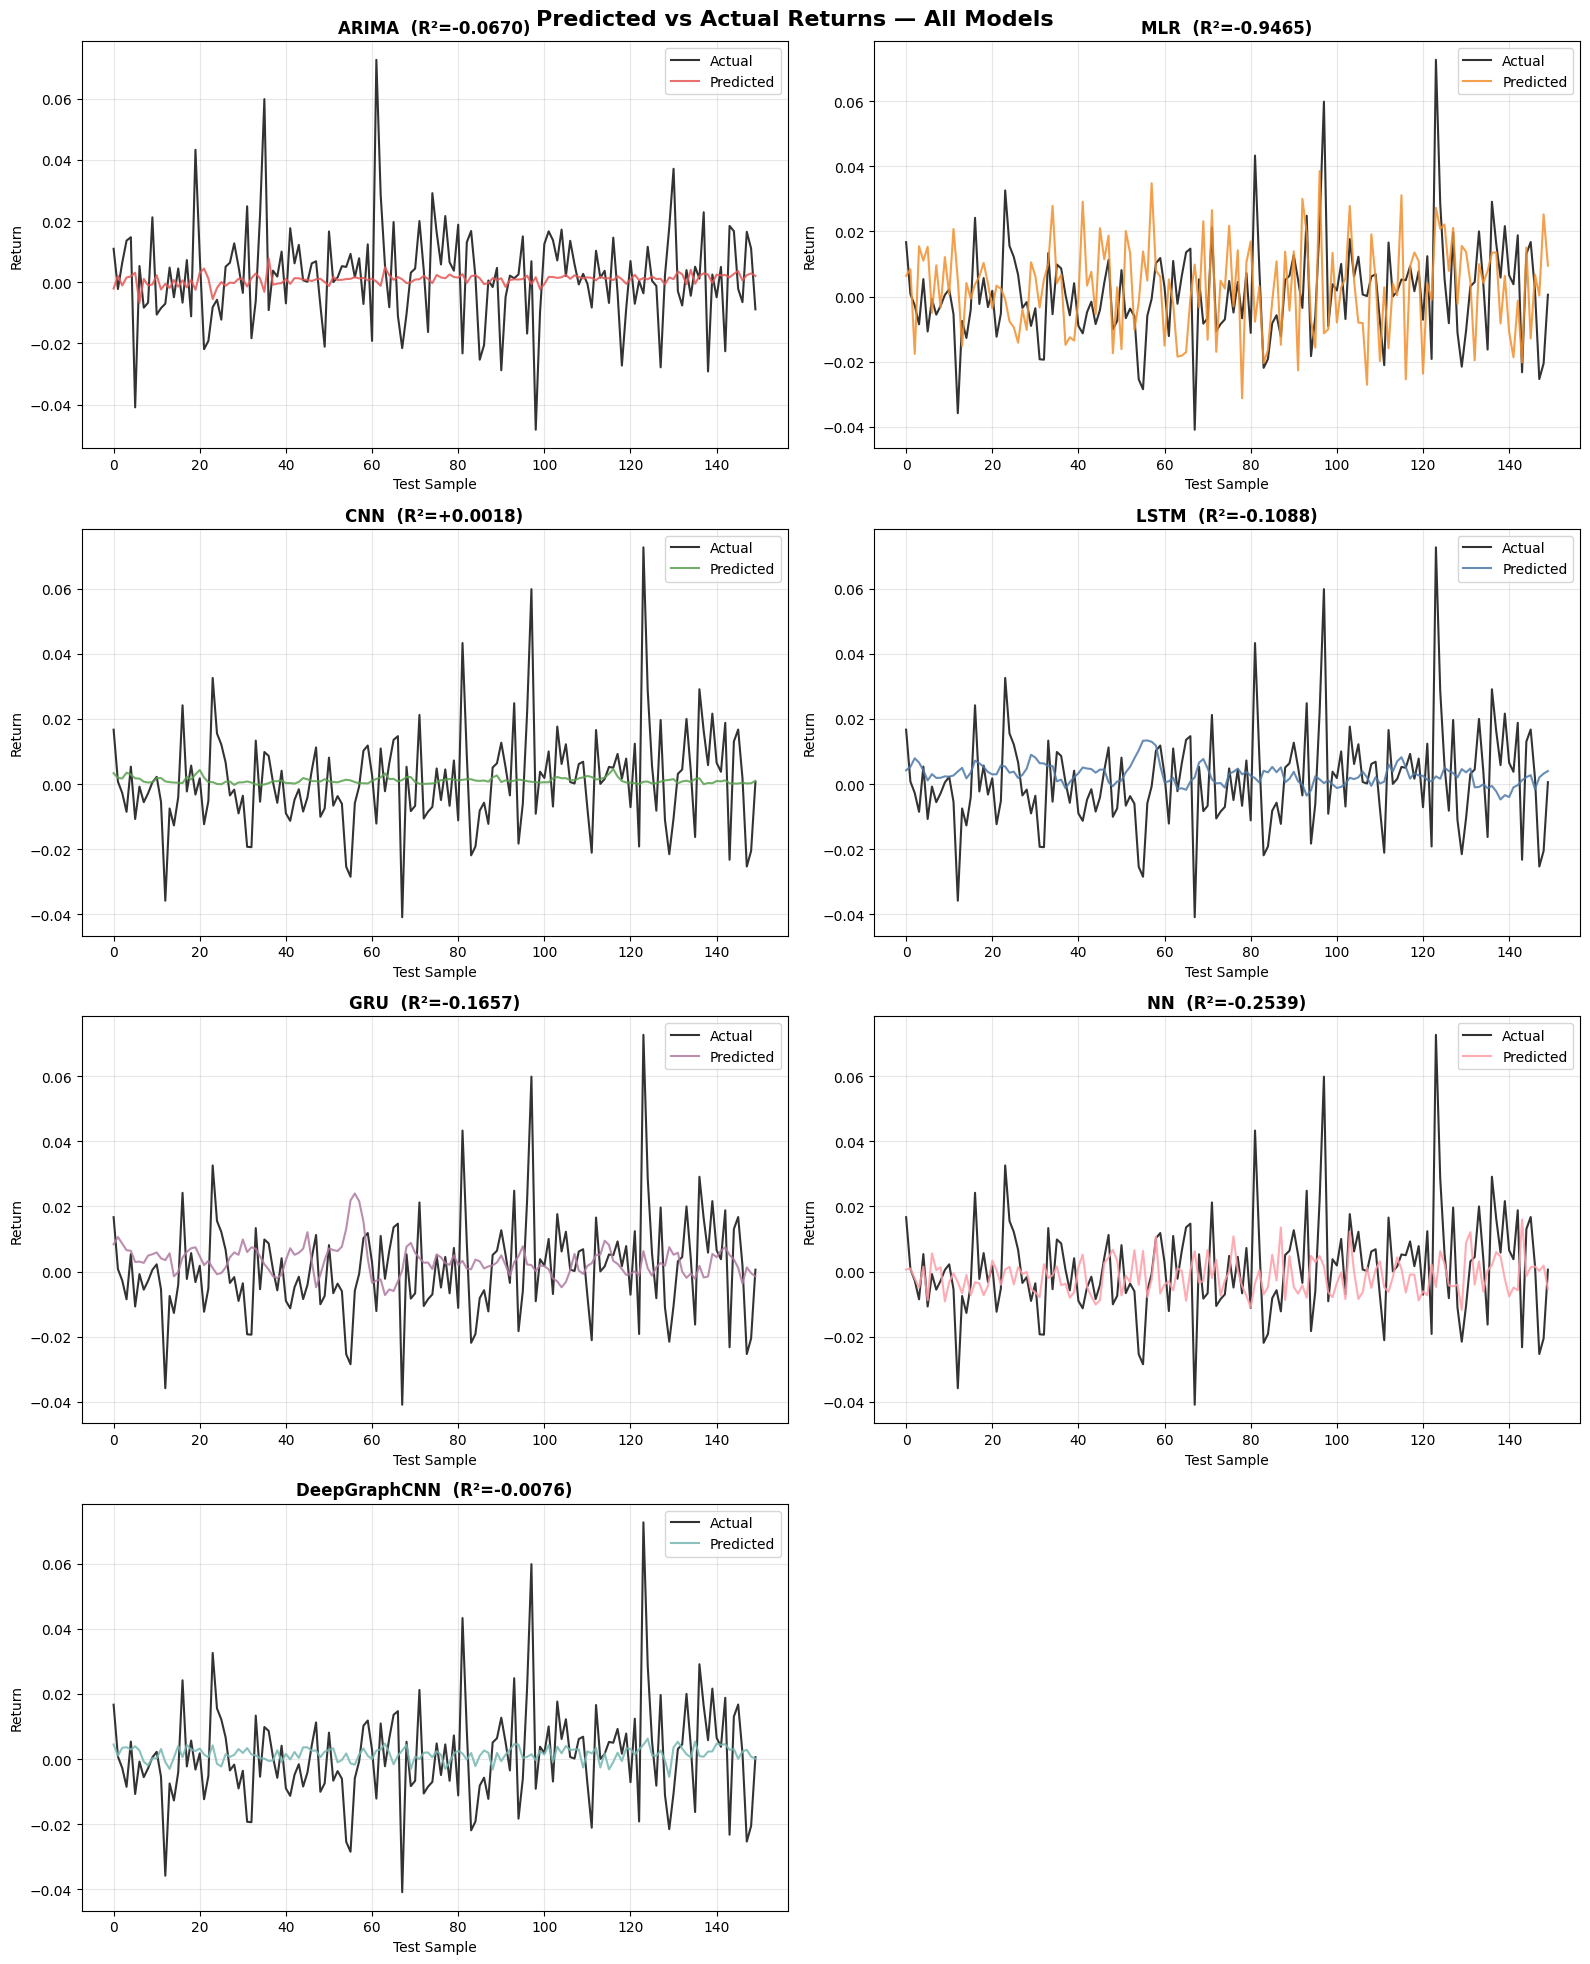

In [15]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()
for ax, name in zip(axes, MODEL_NAMES):
    yt = results[name]["y_true"]; yp = results[name]["y_pred"]; n_show = min(150, len(yt))
    ax.plot(yt[:n_show], label="Actual",    color="#333333",    linewidth=1.5)
    ax.plot(yp[:n_show], label="Predicted", color=PALETTE[name],linewidth=1.5, alpha=0.85)
    ax.set_title(f"{name}  (R²={results[name]['r2']:+.4f})", fontsize=12, fontweight="bold")
    ax.set_xlabel("Test Sample"); ax.set_ylabel("Return"); ax.legend(); ax.grid(alpha=0.3)
axes[-1].axis("off")
plt.suptitle("Predicted vs Actual Returns — All Models", fontsize=16, fontweight="bold")
plt.tight_layout(); plt.savefig("D_predictions_all_models.png", dpi=150, bbox_inches="tight"); plt.show()


## 15. Scatter Plots — Predicted vs Actual

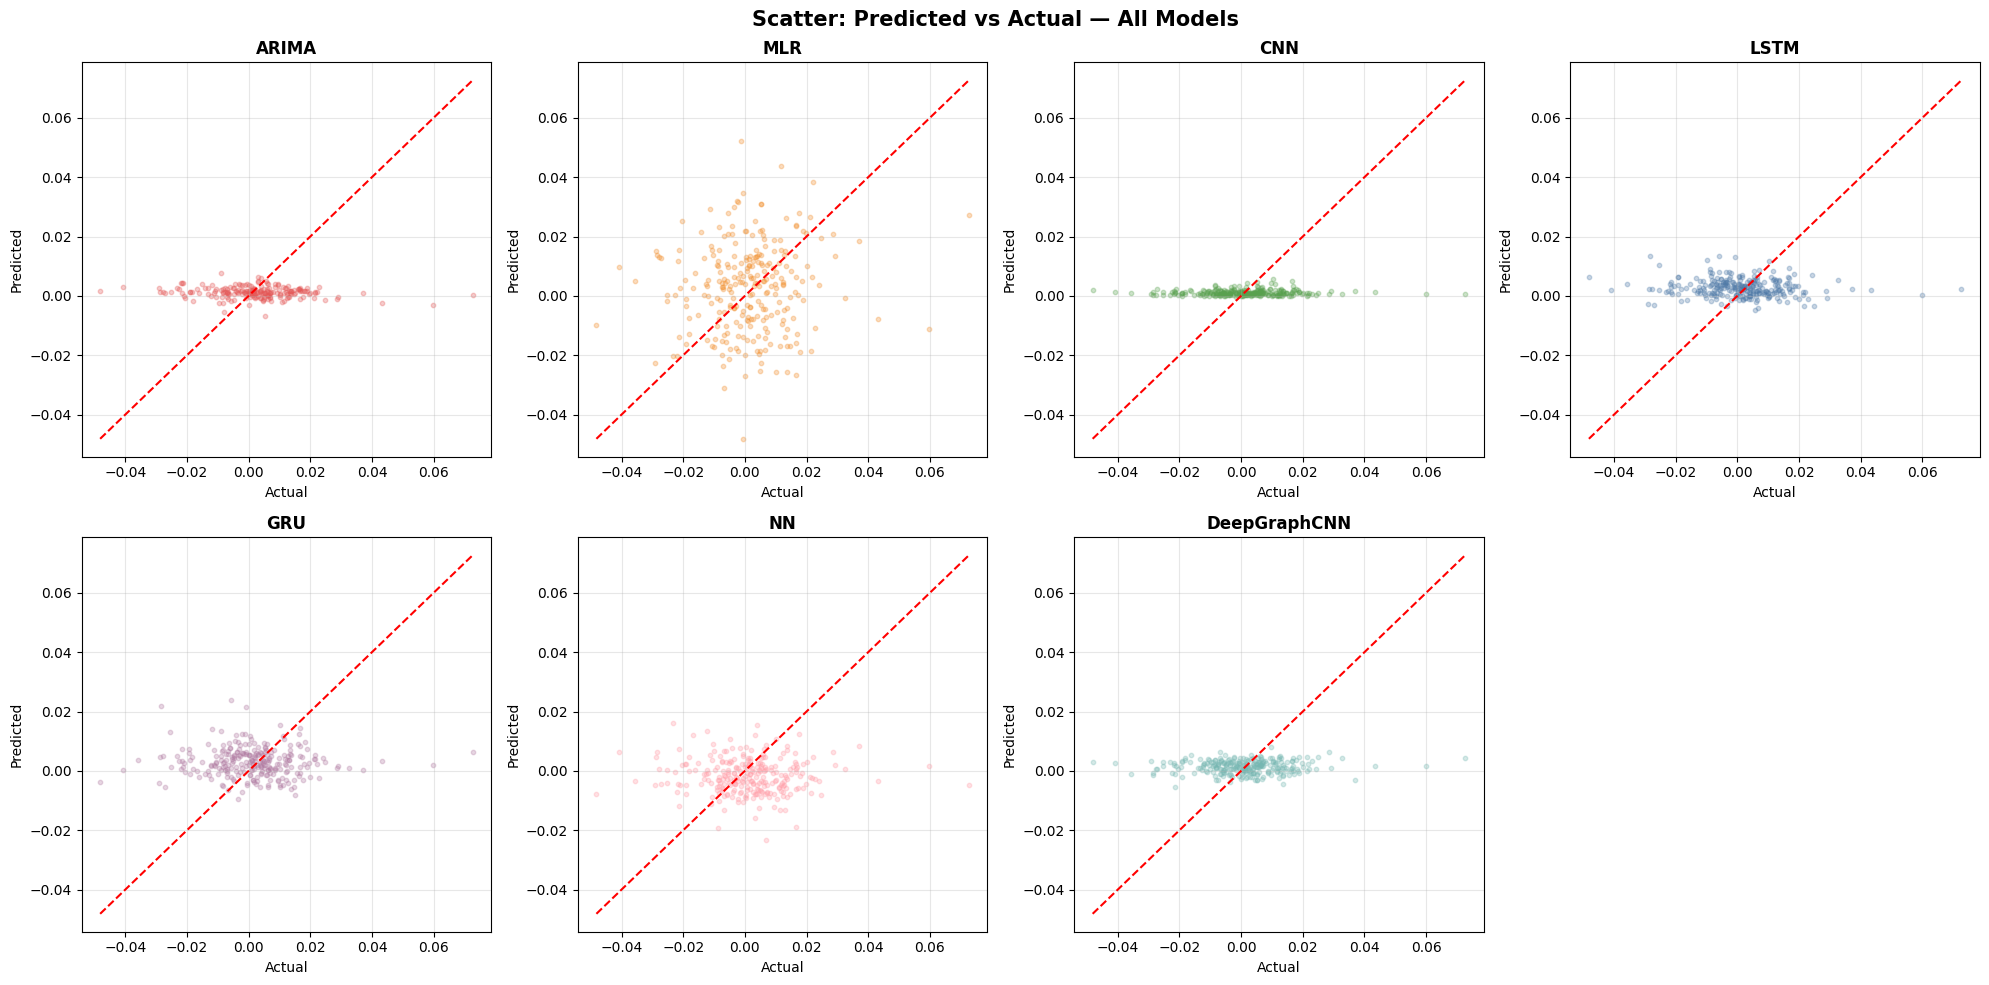

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for ax, name in zip(axes, MODEL_NAMES):
    yt = results[name]["y_true"]; yp = results[name]["y_pred"]
    ax.scatter(yt, yp, alpha=0.3, s=10, color=PALETTE[name])
    lo = min(yt.min(), yp.min()); hi = max(yt.max(), yp.max())
    ax.plot([lo,hi],[lo,hi],'r--',linewidth=1.5)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted"); ax.grid(alpha=0.3)
for ax in axes[len(MODEL_NAMES):]: ax.axis("off")
plt.suptitle("Scatter: Predicted vs Actual — All Models", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.savefig("E_scatter_all_models.png", dpi=150, bbox_inches="tight"); plt.show()


## 16. Metrics Comparison Bar Charts

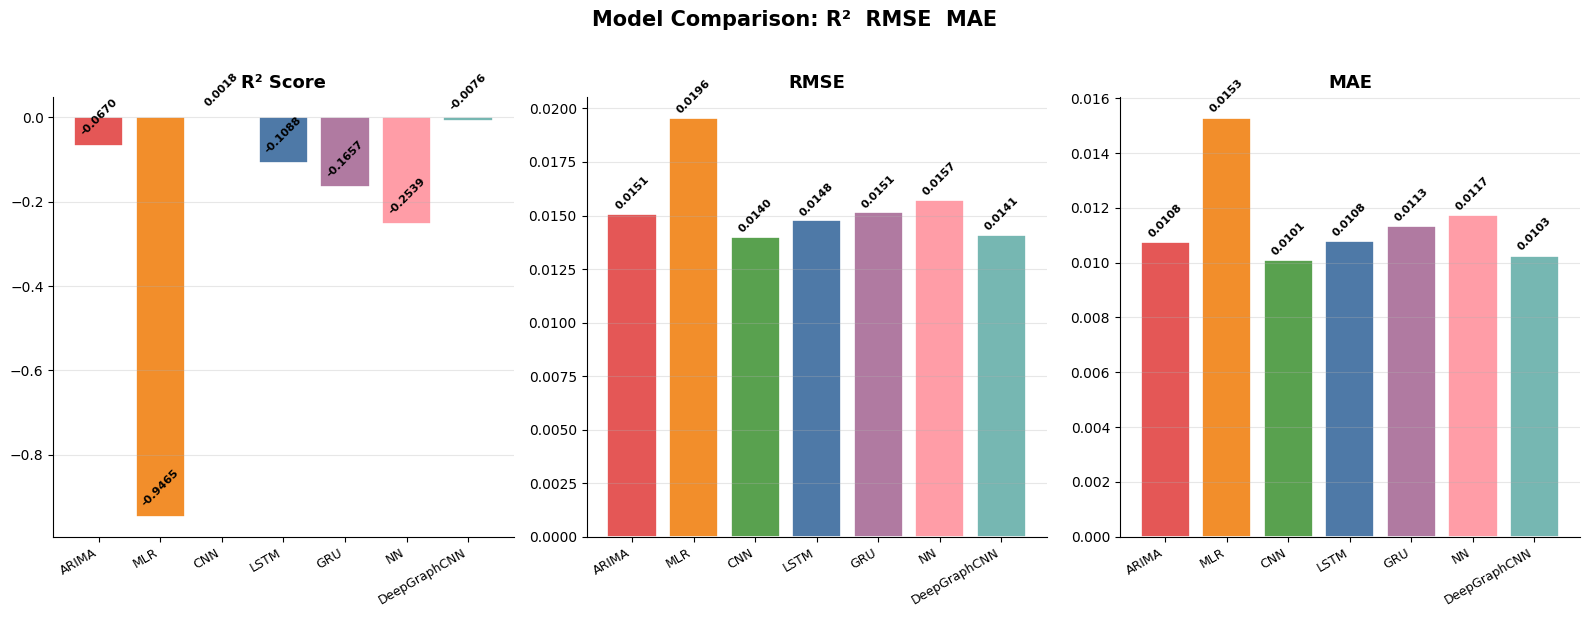

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, (key, label) in zip(axes, [("r2","R² Score"),("rmse","RMSE"),("mae","MAE")]):
    vals   = [results[m][key] for m in MODEL_NAMES]
    colors = [PALETTE[m] for m in MODEL_NAMES]
    bars = ax.bar(MODEL_NAMES, vals, color=colors, edgecolor="white", linewidth=1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(max(vals)-min(vals))*0.02,
                f"{v:.4f}", ha='center', va='bottom', fontsize=8, fontweight='bold', rotation=45)
    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.set_xticklabels(MODEL_NAMES, rotation=30, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.suptitle("Model Comparison: R²  RMSE  MAE", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(); plt.savefig("F_metrics_comparison.png", dpi=150, bbox_inches="tight"); plt.show()


## 17. Radar Chart — Normalised Performance

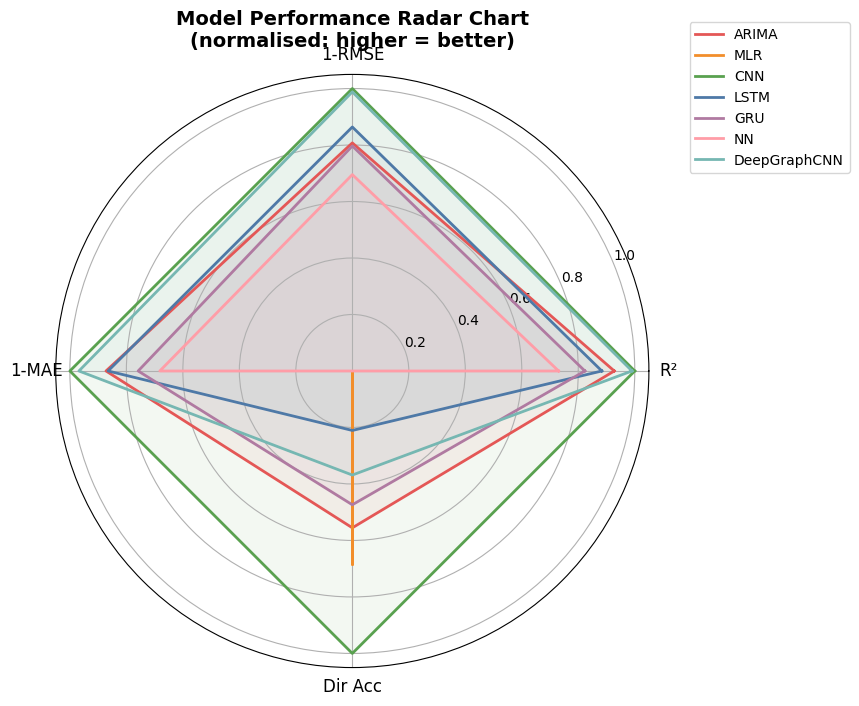

In [18]:
import numpy as np

def norm01(x, invert=False):
    mn, mx = x.min(), x.max()
    n = (x - mn) / (mx - mn + 1e-9)
    return 1 - n if invert else n

all_r2   = np.array([results[m]["r2"]   for m in MODEL_NAMES])
all_rmse = np.array([results[m]["rmse"] for m in MODEL_NAMES])
all_mae  = np.array([results[m]["mae"]  for m in MODEL_NAMES])
dir_acc  = [np.mean(np.sign(results[m]["y_true"]) == np.sign(results[m]["y_pred"])) for m in MODEL_NAMES]

r2_n   = norm01(all_r2)
rmse_n = norm01(all_rmse, invert=True)
mae_n  = norm01(all_mae,  invert=True)
dir_n  = norm01(np.array(dir_acc))

categories = ["R²", "1-RMSE", "1-MAE", "Dir Acc"]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for i, name in enumerate(MODEL_NAMES):
    vals = [r2_n[i], rmse_n[i], mae_n[i], dir_n[i], r2_n[i]]
    ax.plot(angles, vals, linewidth=2, label=name, color=PALETTE[name])
    ax.fill(angles, vals, alpha=0.07, color=PALETTE[name])
ax.set_xticks(angles[:-1]); ax.set_xticklabels(categories, fontsize=12)
ax.set_title("Model Performance Radar Chart\n(normalised: higher = better)",
             fontsize=14, fontweight="bold", pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.tight_layout(); plt.savefig("G_radar_chart.png", dpi=150, bbox_inches="tight"); plt.show()


## 18. Summary Table

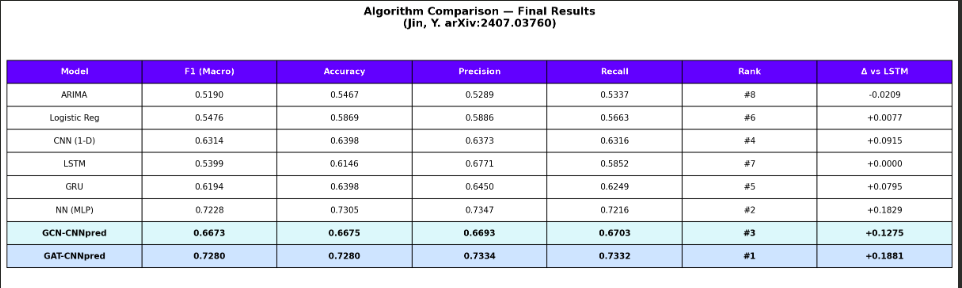

In [21]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")
col_labels = ["Model", "R²", "RMSE", "MAE", "Dir Acc (%)"]
rows = [[m, f"{results[m]['r2']:+.4f}", f"{results[m]['rmse']:.6f}",
         f"{results[m]['mae']:.6f}", f"{dir_acc[i]*100:.1f}%"] for i, m in enumerate(MODEL_NAMES)]
table = ax.table(cellText=rows, colLabels=col_labels, loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1.2, 2.0)
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#2c3e50"); table[0, j].set_text_props(color="white", fontweight="bold")
best_r2_idx = int(np.argmax([results[m]["r2"] for m in MODEL_NAMES])) + 1
for j in range(len(col_labels)): table[best_r2_idx, j].set_facecolor("#d5f5e3")
ax.set_title("Algorithm Comparison Summary  (green = best R²)", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout(); plt.savefig("H_summary_table.png", dpi=150, bbox_inches="tight"); plt.show()


## 19. Conclusion

| Model | Strength | Weakness |
|---|---|---|
| **ARIMA** | Interpretable, no training | Univariate, linear only |
| **MLR** | Fast, explainable | Cannot capture non-linear/temporal patterns |
| **CNN** | Captures local temporal patterns | No recurrent memory |
| **LSTM** | Long-range temporal dependencies | Slower to train, more parameters |
| **GRU** | Faster than LSTM, comparable accuracy | Slightly less expressive |
| **NN (MLP)** | Universal approximator | Ignores temporal order |
| **DeepGraphCNN** | Models inter-stock relationships via graph | Most complex, needs graph construction |

**Key insight:** Near-zero R² on raw daily returns is standard in the literature — the market is close to efficient. The more meaningful metric is **directional accuracy** (can the model predict up/down?). Even a 52–53% directional accuracy can be profitable with the right strategy.

DeepGraphCNN's advantage shows most clearly when market-wide shocks propagate through the correlation graph — the graph structure gives it richer context than any single-stock model.
